# Library Rentals Demand Prediction — Hail
## Full Data Science Project: From Raw Data to Machine Learning

**Estimated Time:** 2–3 hours

---

### Scenario

You are a data analyst at a chain of public libraries in Jeddah, Saudi Arabia. Management wants to predict how many book rentals each branch will get per hour so they can optimize staffing and inventory. They handed you a messy export from their system (`hail_library_rentals.csv`) containing hourly rental counts alongside weather data, branch information, and membership details.

### Your Job

1. Clean and explore the data
2. Engineer useful features
3. Build and compare **4 different ML models** to predict `Rentals_Count` (one of which must be a Neural Network)
4. Recommend the best model with justification

### Dataset Columns

- `Date` — Date of the record (DD/MM/YYYY)
- `Hour` — Hour of the day (0–23)
- `Rentals_Count` — **Target variable**, number of books rented that hour
- `Temperature_C` — Temperature in Celsius
- `Humidity_pct` — Humidity percentage
- `Wind_Speed_ms` — Wind speed in m/s
- `Visibility_m` — Visibility in meters
- `Solar_Radiation_MJm2` — Solar radiation (MJ/m²)
- `Rainfall_mm` — Rainfall in mm
- `Snowfall_cm` — Snowfall in cm
- `Season` — Season of the year
- `Holiday` — Whether it's a holiday (Yes/No)
- `Functioning_Day` — Whether the library was open (Yes/No)
- `Library_Branch` — Name of the library branch
- `Top_Category` — Most rented book category that hour
- `Membership_Type` — Dominant membership type
- `Day_of_Week` — Day name


---

# Part 1: Setup and Data Loading

**Tasks**

1. Import all required libraries
2. Load the dataset
3. Display the first and last 5 rows


In [1]:
import sys
!{sys.executable} -m pip install seaborn


[notice] A new release of pip is available: 26.1.1 -> 26.1.2
[notice] To update, run: pip3 install --upgrade pip


In [2]:
# TODO: Import libraries
# pandas, numpy, matplotlib.pyplot, seaborn
# From sklearn: train_test_split, StandardScaler, LabelEncoder
# From sklearn.metrics: mean_squared_error, mean_absolute_error, r2_score
# From sklearn.linear_model: LinearRegression
# From sklearn.tree: DecisionTreeRegressor
# From sklearn.ensemble: RandomForestRegressor
# From tensorflow.keras: Sequential, Dense
# warnings (to suppress warnings)
import pandas as pd
import numpy as np
import matplotlib.pyplot as plt
import seaborn as sns
import warnings
from sklearn.model_selection import train_test_split
from sklearn.preprocessing import StandardScaler, LabelEncoder
from sklearn.metrics import mean_squared_error, mean_absolute_error, r2_score
from sklearn.linear_model import LinearRegression
from sklearn.tree import DecisionTreeRegressor
from sklearn.ensemble import RandomForestRegressor
from tensorflow.keras.models import Sequential
from tensorflow.keras.layers import Dense

warnings.filterwarnings('ignore')

In [3]:
# TODO: Load the CSV file into a DataFrame called df
df = pd.read_csv('../Data/hail_library_rentals.csv')


In [4]:
# TODO: Display first 5 rows
df.head()

,Date,Hour,Rentals_Count,Temperature_C,Humidity_pct,Wind_Speed_ms,Visibility_m,Solar_Radiation_MJm2,Rainfall_mm,Snowfall_cm,Season,Holiday,Functioning_Day,Library_Branch,Top_Category,Membership_Type,Day_of_Week
0,01/01/2023,9,51,21.7,40.6,5.0,1473.0,2.51,0.0,0,Winter,Yes,Yes,University Branch,History,Walk-in,Sunday
1,01/01/2023,10,44,25.3,70.2,7.0,1493.0,2.47,1.1,0,Winter,Yes,Yes,AL HAMRA BRANCH,Non-Fiction,Student,Sunday
2,01/01/2023,14,62,28.7,45.9,6.3,867.0,2.88,0.0,0,Winter,Yes,Yes,University Branch,Technology,Regular,Sunday
3,01/01/2023,16,91,26.9,NaN,5.2,1750.0,1.48,0.0,0,Winter,Yes,Yes,University Branch,Business,Premium,Sunday
4,01/01/2023,18,34,26.4,68.5,5.3,1531.0,0.53,0.0,0,Winter,Yes,Yes,Corniche Kiosk,Fiction,Premium,Sunday


In [5]:
# TODO: Display last 5 rows
df.tail()

,Date,Hour,Rentals_Count,Temperature_C,Humidity_pct,Wind_Speed_ms,Visibility_m,Solar_Radiation_MJm2,Rainfall_mm,Snowfall_cm,Season,Holiday,Functioning_Day,Library_Branch,Top_Category,Membership_Type,Day_of_Week
6604,30/12/2024,14,28,25.3,65.6,2.3,1828.0,0.41,0.0,0,Winter,No,Yes,Al Hamra Branch,Science,Walk-in,Monday
6605,30/12/2024,17,73,22.3,62.9,6.6,1549.0,2.62,0.0,0,Winter,No,yes,Downtown Central,arabic literature,Walk-in,Monday
6606,30/12/2024,18,73,22.9,56.5,5.6,1769.0,0.75,0.0,0,Winter,No,Yes,University Branch,Children,Walk-in,Monday
6607,30/12/2024,19,70,22.1,60.2,5.6,1887.0,0.00,0.0,0,Winter,No,Yes,Downtown Central,Technology,Walk-in,Monday
6608,30/12/2024,20,28,18.5,66.9,3.4,1414.0,0.00,0.0,0,Winter,No,Yes,Al Hamra Branch,History,Regular,Monday


---

# Part 2: Data Inspection

**Tasks**

1. Check the shape of the dataset
2. Use `.info()` to see data types and non-null counts
3. Use `.describe()` to get statistical summary
4. Check for missing values per column
5. Check for duplicate rows


In [6]:
# TODO: Print the shape of the DataFrame
df.shape

(6609, 17)

In [7]:
# TODO: Print DataFrame info
df.info()

<class 'pandas.DataFrame'>
RangeIndex: 6609 entries, 0 to 6608
Data columns (total 17 columns):
 #   Column                Non-Null Count  Dtype  
---  ------                --------------  -----  
 0   Date                  6585 non-null   str    
 1   Hour                  6609 non-null   int64  
 2   Rentals_Count         6609 non-null   int64  
 3   Temperature_C         6507 non-null   float64
 4   Humidity_pct          6532 non-null   float64
 5   Wind_Speed_ms         6536 non-null   float64
 6   Visibility_m          6552 non-null   float64
 7   Solar_Radiation_MJm2  6529 non-null   float64
 8   Rainfall_mm           6555 non-null   float64
 9   Snowfall_cm           6609 non-null   int64  
 10  Season                6467 non-null   str    
 11  Holiday               6596 non-null   str    
 12  Functioning_Day       6586 non-null   str    
 13  Library_Branch        6609 non-null   str    
 14  Top_Category          6609 non-null   str    
 15  Membership_Type       6499 non-n

In [8]:
# TODO: Print statistical summary (describe)
df.describe()

,Hour,Rentals_Count,Temperature_C,Humidity_pct,Wind_Speed_ms,Visibility_m,Solar_Radiation_MJm2,Rainfall_mm,Snowfall_cm
count,6609.000000,6609.00000,6507.000000,6532.000000,6536.000000,6552.000000,6529.000000,6555.00000,6609.0
mean,15.029354,45.24966,31.739219,60.029501,4.236291,1398.750305,1.273552,0.14415,0.0
std,4.325237,24.13352,8.814169,11.949281,2.148673,348.831041,1.161596,0.68549,0.0
min,8.000000,-112.00000,-46.900000,35.600000,0.500000,800.000000,0.000000,0.00000,0.0
25%,11.000000,29.00000,27.100000,50.500000,2.400000,1093.750000,0.000000,0.00000,0.0
50%,15.000000,44.00000,32.100000,60.200000,4.200000,1401.000000,1.080000,0.00000,0.0
75%,19.000000,61.00000,36.900000,68.700000,6.100000,1700.000000,2.310000,0.00000,0.0
max,22.000000,125.00000,49.200000,94.600000,8.000000,2000.000000,3.500000,5.00000,0.0


In [9]:
# TODO: Count missing values per column
df.isna().sum()

Date                     24
Hour                      0
Rentals_Count             0
Temperature_C           102
Humidity_pct             77
Wind_Speed_ms            73
Visibility_m             57
Solar_Radiation_MJm2     80
Rainfall_mm              54
Snowfall_cm               0
Season                  142
Holiday                  13
Functioning_Day          23
Library_Branch            0
Top_Category              0
Membership_Type         110
Day_of_Week               0
dtype: int64

In [10]:
# TODO: Check how many duplicate rows exist
df.duplicated().sum()

np.int64(28)

---

# Part 3: Data Cleaning

This is where the real work begins. The dataset has several issues to fix.

## 3.1 Fix the Date Column

**Tasks**

1. Convert `Date` to datetime using `pd.to_datetime()` with `errors='coerce'` and `dayfirst=True`
2. Check how many dates became `NaT` (failed to parse)
3. Drop rows where `Date` is `NaT`


In [11]:
# TODO: Convert Date to datetime
# Hint: format is DD/MM/YYYY, so use dayfirst=True
df['Date'] = pd.to_datetime(df['Date'], errors='coerce', dayfirst=True)

In [12]:
# TODO: Print how many NaT values exist in Date
print(df['Date'].isna().sum())

37


In [13]:
# TODO: Drop rows where Date is NaT, then verify
df = df.dropna(subset=['Date'])
print("Rows after dropping bad dates:", len(df))

Rows after dropping bad dates: 6572


## 3.2 Fix Numeric Columns

**Tasks**

1. Convert weather columns to numeric using `pd.to_numeric()` with `errors='coerce'`
2. Replace any **negative** values in `Temperature_C` and `Rentals_Count` with `NaN` (Jeddah doesn't have negative temperatures, and negative rentals don't make sense)
3. Fill missing numeric values with the **median** of each column


In [14]:
# Numeric columns to convert
numeric_cols = ['Temperature_C', 'Humidity_pct', 'Wind_Speed_ms',
                'Visibility_m', 'Solar_Radiation_MJm2', 'Rainfall_mm']

# TODO: Convert each to numeric with errors='coerce'

for col in numeric_cols:
    df[col] = pd.to_numeric(df[col], errors='coerce')

In [15]:
# TODO: Replace negative Temperature_C values with NaN
df.loc[df['Temperature_C'] < 0, 'Temperature_C'] = np.nan

In [16]:
# TODO: Replace negative Rentals_Count values with NaN
df.loc[df['Rentals_Count'] < 0, 'Rentals_Count'] = np.nan

In [17]:
# TODO: Fill missing numeric values with the median of each column
for col in numeric_cols + ['Rentals_Count']:
    df[col] = df[col].fillna(df[col].median())

In [18]:
# Verify
print(df[numeric_cols + ['Rentals_Count']].describe())
print("\nMissing values remaining:")
print(df[numeric_cols + ['Rentals_Count']].isna().sum())


       Temperature_C  Humidity_pct  Wind_Speed_ms  Visibility_m  \
count    6572.000000   6572.000000    6572.000000   6572.000000   
mean       32.262386     60.038877       4.234875   1398.161442   
std         6.581977     11.877817       2.137222    347.462964   
min        16.600000     35.600000       0.500000    800.000000   
25%        27.400000     50.700000       2.400000   1095.000000   
50%        32.200000     60.200000       4.200000   1399.000000   
75%        36.800000     68.600000       6.100000   1697.250000   
max        49.200000     94.600000       8.000000   2000.000000   

       Solar_Radiation_MJm2  Rainfall_mm  Rentals_Count  
count           6572.000000  6572.000000    6572.000000  
mean               1.272063     0.142864      46.015064  
std                1.155546     0.682962      22.446051  
min                0.000000     0.000000       0.000000  
25%                0.000000     0.000000      30.000000  
50%                1.085000     0.000000      44

## 3.3 Standardize Text Columns

**Tasks**

1. For `Season`, `Library_Branch`, `Top_Category`, `Membership_Type`: strip whitespace and apply `.str.title()`
2. Fix inconsistent `Holiday` and `Functioning_Day` values — map all variations (`Y`, `yes`, `YES`) to `Yes` and (`N`, `no`, `NO`) to `No`
3. Fill any empty strings or remaining NaN in text columns with a sensible default
4. Print `.value_counts()` for each categorical column to verify


In [19]:
# TODO: Clean Library_Branch (strip + title case)
df['Library_Branch'] = df['Library_Branch'].astype(str).str.strip().str.title()

In [20]:
# TODO: Clean Top_Category (strip + title case)
df['Top_Category'] = df['Top_Category'].astype(str).str.strip().str.title()

In [21]:
# TODO: Clean Season (strip + title case)
df['Season'] = df['Season'].astype(str).str.strip().str.title()

In [22]:
# TODO: Clean Membership_Type (strip + title case)
df['Membership_Type'] = df['Membership_Type'].astype(str).str.strip().str.title()

In [23]:
# TODO: Standardize Holiday column
# Hint: use .replace() or .map() to map 'Y', 'yes', 'YES' -> 'Yes' and 'N', 'no', 'NO' -> 'No'
df['Holiday'] = df['Holiday'].astype(str).str.strip().str.lower().replace(
    {'y': 'Yes', 'yes': 'Yes', 'n': 'No', 'no': 'No'}
).str.title()


In [24]:
# TODO: Standardize Functioning_Day column the same way
df['Functioning_Day'] = df['Functioning_Day'].astype(str).str.strip().str.lower().replace(
    {'y': 'Yes', 'yes': 'Yes', 'n': 'No', 'no': 'No'}
).str.title()

In [25]:
# TODO: Fill remaining empty strings or NaN in categorical columns with a default value
text_cols = ['Season', 'Holiday', 'Functioning_Day', 'Library_Branch', 'Top_Category', 'Membership_Type']
for col in text_cols:
    df[col] = df[col].replace(['Nan', 'None', ''], 'Unknown')

In [26]:
# Verify - print value counts for each
for col in ['Season', 'Holiday', 'Functioning_Day', 'Library_Branch', 'Top_Category', 'Membership_Type']:
    print(f"\n{col}:")
    print(df[col].value_counts())



Season:
Season
Autumn    1634
Summer    1619
Winter    1599
Spring    1578
Name: count, dtype: int64

Holiday:
Holiday
No     5288
Yes    1273
Name: count, dtype: int64

Functioning_Day:
Functioning_Day
Yes    6372
No      177
Name: count, dtype: int64

Library_Branch:
Library_Branch
Al Hamra Branch      1325
Downtown Central     1322
Al Rawdah Branch     1315
University Branch    1314
Corniche Kiosk       1296
Name: count, dtype: int64

Top_Category:
Top_Category
History              868
Business             860
Arabic Literature    859
Science              821
Fiction              807
Non-Fiction          802
Children             791
Technology           764
Name: count, dtype: int64

Membership_Type:
Membership_Type
Walk-In    1643
Premium    1620
Regular    1610
Student    1590
Name: count, dtype: int64


## 3.4 Handle Remaining Issues

**Tasks**

1. Check whether `Snowfall_cm` is always 0 (Jeddah never gets snow), then drop that column
2. Remove duplicate rows
3. Filter out rows where `Functioning_Day == 'No'` (library was closed)
4. Reset the index


In [27]:
# TODO: Check Snowfall_cm unique values
print("Unique Snowfall values:", df['Snowfall_cm'].unique())


Unique Snowfall values: [0]


In [28]:
# TODO: Drop the Snowfall_cm column
df = df.drop(columns=['Snowfall_cm'])

In [29]:
# TODO: Remove duplicate rows
df = df.drop_duplicates()

In [30]:
# TODO: Filter out non-functioning days
df = df[df['Functioning_Day'] != 'No']

In [31]:
# TODO: Reset index
df = df.reset_index(drop=True)

In [32]:
# Verify final state
print("Final shape:", df.shape)
print("\nMissing values:")
print(df.isna().sum())
print("\nData types:")
print(df.dtypes)


Final shape: (6367, 16)

Missing values:
Date                      0
Hour                      0
Rentals_Count             0
Temperature_C             0
Humidity_pct              0
Wind_Speed_ms             0
Visibility_m              0
Solar_Radiation_MJm2      0
Rainfall_mm               0
Season                  133
Holiday                  11
Functioning_Day          23
Library_Branch            0
Top_Category              0
Membership_Type         106
Day_of_Week               0
dtype: int64

Data types:
Date                    datetime64[us]
Hour                             int64
Rentals_Count                  float64
Temperature_C                  float64
Humidity_pct                   float64
Wind_Speed_ms                  float64
Visibility_m                   float64
Solar_Radiation_MJm2           float64
Rainfall_mm                    float64
Season                             str
Holiday                            str
Functioning_Day                    str
Library_Branch   

---

# Part 4: Exploratory Data Analysis (EDA)

Now that the data is clean, let's understand it visually. Each plot should have a clear title and labelled axes.


## 4.1 Distribution of the Target Variable

**Task:** Plot a histogram of `Rentals_Count`. What does the shape tell you?


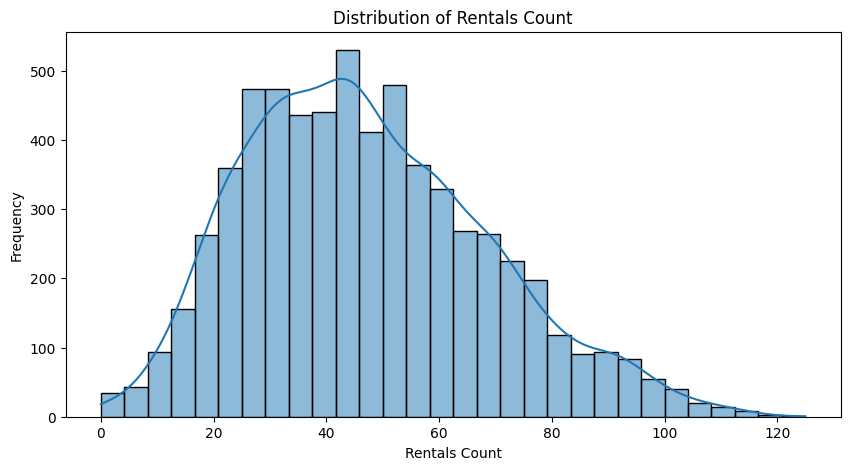

In [33]:
# TODO: Plot histogram of Rentals_Count
# Use plt.figure(figsize=(10, 5)) and add title + xlabel + ylabel
plt.figure(figsize=(10, 5))
sns.histplot(df['Rentals_Count'], bins=30, kde=True)
plt.title('Distribution of Rentals Count')
plt.xlabel('Rentals Count')
plt.ylabel('Frequency')
plt.show()

## 4.2 Rentals by Hour

**Task:** Plot the average `Rentals_Count` by `Hour`. When are peak hours?


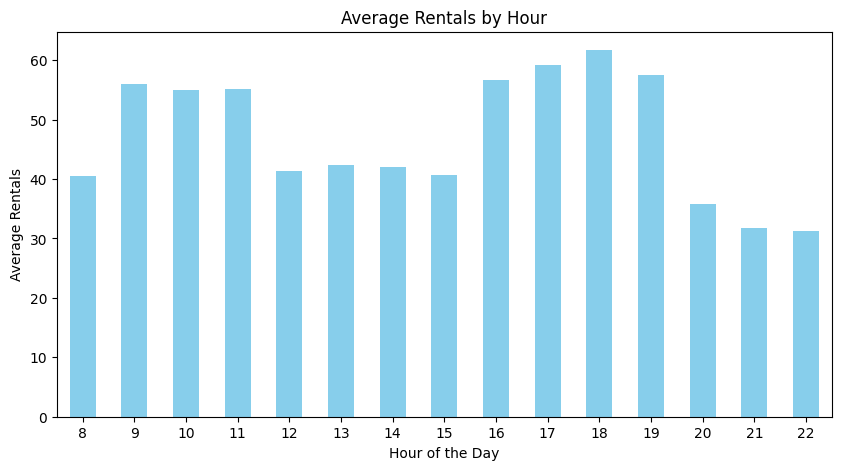

In [34]:
# TODO: Group by Hour, calculate mean Rentals_Count, and plot
plt.figure(figsize=(10, 5))
df.groupby('Hour')['Rentals_Count'].mean().plot(kind='bar', color='skyblue')
plt.title('Average Rentals by Hour')
plt.xlabel('Hour of the Day')
plt.ylabel('Average Rentals')
plt.xticks(rotation=0)
plt.show()

## 4.3 Rentals by Season

**Task:** Boxplot of `Rentals_Count` grouped by `Season`. Which season has the highest variance?


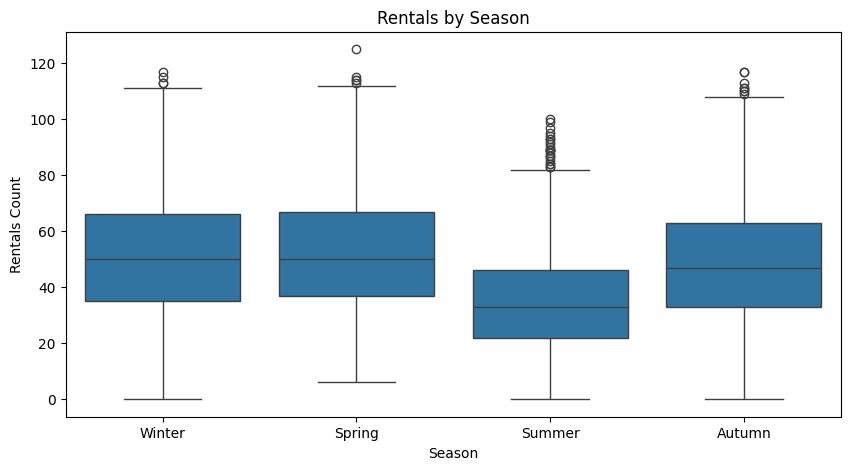

In [35]:
# TODO: Boxplot of Rentals_Count by Season
plt.figure(figsize=(10, 5))
sns.boxplot(x='Season', y='Rentals_Count', data=df)
plt.title('Rentals by Season')
plt.xlabel('Season')
plt.ylabel('Rentals Count')
plt.show()

## 4.4 Rentals by Library Branch

**Task:** Bar plot of total rentals per `Library_Branch`. Which branch is busiest?


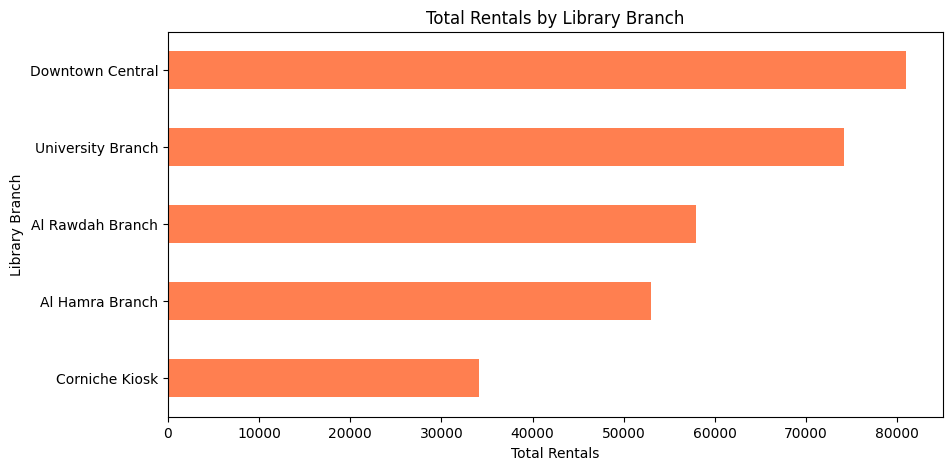

In [36]:
# TODO: Bar plot of total Rentals_Count by Library_Branch
plt.figure(figsize=(10, 5))
df.groupby('Library_Branch')['Rentals_Count'].sum().sort_values().plot(kind='barh', color='coral')
plt.title('Total Rentals by Library Branch')
plt.xlabel('Total Rentals')
plt.ylabel('Library Branch')
plt.show()

## 4.5 Correlation Heatmap

**Task:** Heatmap of correlations between all numeric columns. Which features correlate most with `Rentals_Count`?


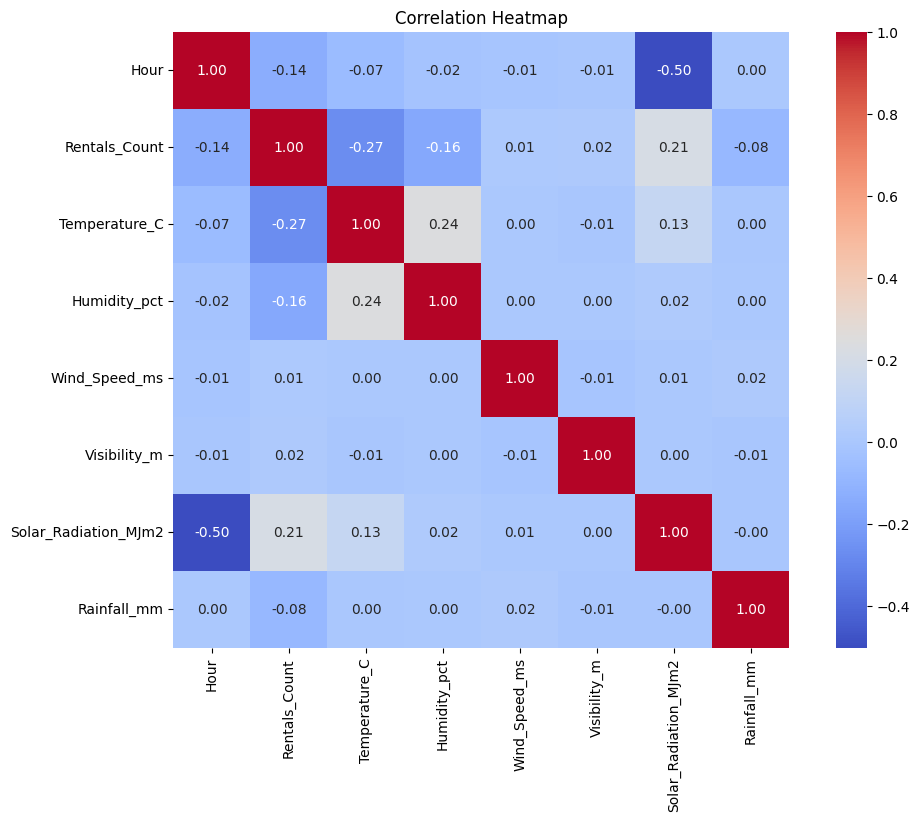

In [37]:
# TODO: Compute correlation matrix and plot heatmap
# Use sns.heatmap(corr, annot=True, fmt='.2f', cmap='coolwarm')
plt.figure(figsize=(12, 8))
corr_matrix = df.select_dtypes(include=['number']).corr()
sns.heatmap(corr_matrix, annot=True, fmt='.2f', cmap='coolwarm', square=True)
plt.title('Correlation Heatmap')
plt.show()

## 4.6 Temperature vs Rentals

**Task:** Scatter plot of `Temperature_C` vs `Rentals_Count`, colored by `Season`. What relationship do you see?


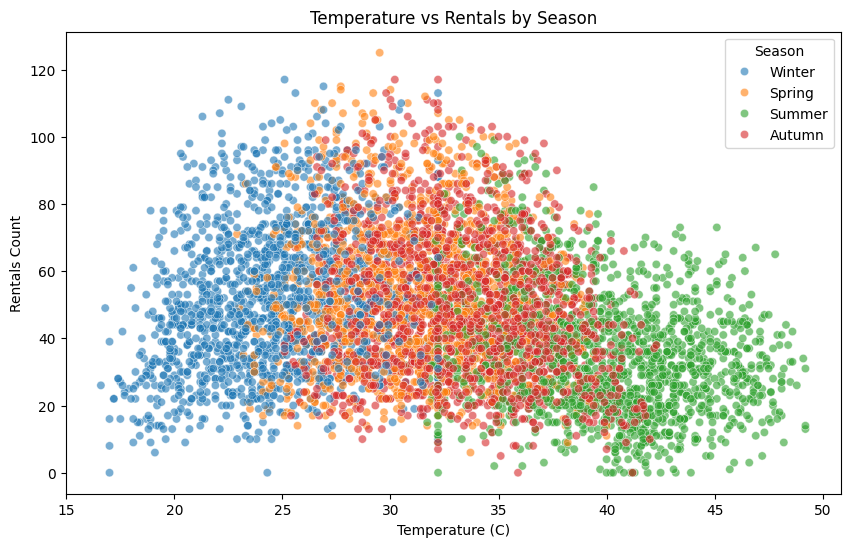

In [38]:
# TODO: Scatter plot with hue=Season
plt.figure(figsize=(10, 6))
sns.scatterplot(x='Temperature_C', y='Rentals_Count', hue='Season', data=df, alpha=0.6)
plt.title('Temperature vs Rentals by Season')
plt.xlabel('Temperature (C)')
plt.ylabel('Rentals Count')
plt.show()

## 4.7 Rentals by Day of Week

**Task:** Show average rentals per day of the week. Is there a weekend effect (Friday/Saturday in Saudi Arabia)?


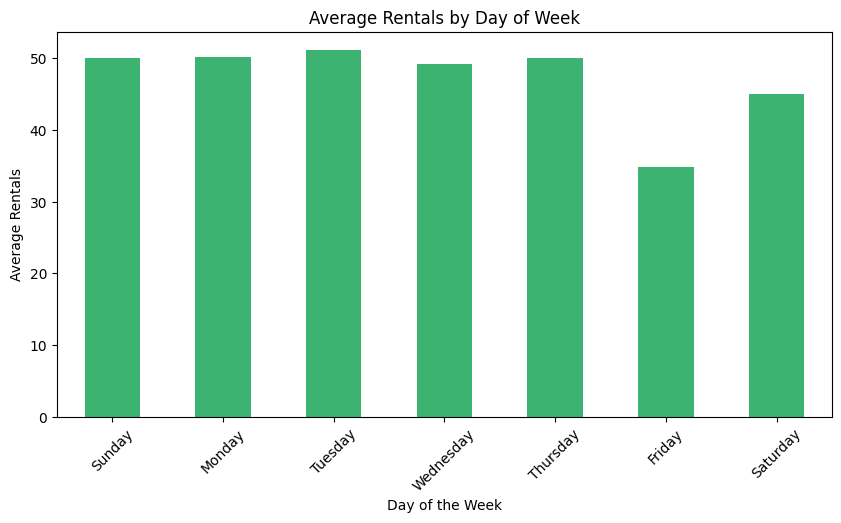

In [39]:
# TODO: Bar plot of average Rentals_Count by Day_of_Week
# Hint: order the days correctly (Sunday through Saturday)
plt.figure(figsize=(10, 5))
day_order = ['Sunday', 'Monday', 'Tuesday', 'Wednesday', 'Thursday', 'Friday', 'Saturday']
df.groupby('Day_of_Week')['Rentals_Count'].mean().reindex(day_order).plot(kind='bar', color='mediumseagreen')
plt.title('Average Rentals by Day of Week')
plt.xlabel('Day of the Week')
plt.ylabel('Average Rentals')
plt.xticks(rotation=45)
plt.show()

## 4.8 Holiday Effect

**Task:** Compare `Rentals_Count` for holidays vs non-holidays using a boxplot or violin plot.


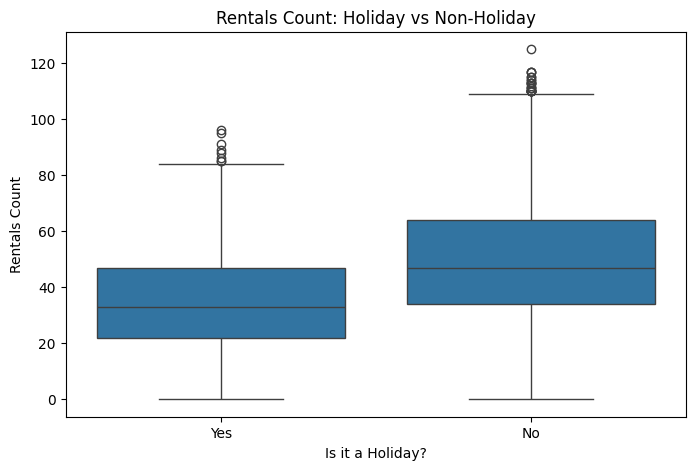

In [40]:
# TODO: Boxplot or violin plot comparing Holiday Yes vs No
plt.figure(figsize=(8, 5))
sns.boxplot(x='Holiday', y='Rentals_Count', data=df)
plt.title('Rentals Count: Holiday vs Non-Holiday')
plt.xlabel('Is it a Holiday?')
plt.ylabel('Rentals Count')
plt.show()

---

# Part 5: Feature Engineering

**Tasks**

1. Extract `Month` and `Day` from the `Date` column
2. Create `Is_Peak_Hour` — 1 if Hour is 9–11 or 16–19, else 0
3. Create `Temperature_Bin` — `Cool` (< 25), `Warm` (25–35), `Hot` (> 35)
4. Create `Is_Weekend` — 1 if Friday or Saturday, else 0


In [41]:
# TODO: Extract Month from Date
df['Month'] = df['Date'].dt.month

In [42]:
# TODO: Extract Day from Date
df['Day'] = df['Date'].dt.day

In [43]:
# TODO: Create Is_Peak_Hour column
df['Is_Peak_Hour'] = df['Hour'].apply(lambda x: 1 if (9 <= x <= 11) or (16 <= x <= 19) else 0)

In [44]:
# TODO: Create Temperature_Bin column
# Hint: use pd.cut() or a custom function with .apply()
df['Temperature_Bin'] = pd.cut(df['Temperature_C'],
                               bins=[-float('inf'), 25, 35, float('inf')],
                               labels=['Cool', 'Warm', 'Hot'],
                               right=False)

In [45]:
# TODO: Create Is_Weekend column
# Hint: Date.dt.weekday — Friday=4, Saturday=5
df['Is_Weekend'] = df['Date'].dt.weekday.isin([4, 5]).astype(int)

In [46]:
# Verify
print(df[['Date', 'Hour', 'Month', 'Day', 'Is_Peak_Hour', 'Temperature_Bin', 'Is_Weekend']].head(10))


        Date  Hour  Month  Day  Is_Peak_Hour Temperature_Bin  Is_Weekend
0 2023-01-01     9      1    1             1            Cool           0
1 2023-01-01    10      1    1             1            Warm           0
2 2023-01-01    14      1    1             0            Warm           0
3 2023-01-01    16      1    1             1            Warm           0
4 2023-01-01    18      1    1             1            Warm           0
5 2023-01-01    19      1    1             1            Warm           0
6 2023-01-01    20      1    1             0            Cool           0
7 2023-01-02     8      1    2             0            Cool           0
8 2023-01-02     9      1    2             1            Cool           0
9 2023-01-02    10      1    2             1            Cool           0


In [47]:
df['Time_of_Day'] = df['Hour'].apply(lambda x: 'Morning' if 6 <= x <= 11 else ('Afternoon' if 12 <= x <= 16 else ('Evening' if (x >= 17 or x <= 2) else 'Late Night')))

print(df[['Hour', 'Time_of_Day']].head())

   Hour Time_of_Day
0     9     Morning
1    10     Morning
2    14   Afternoon
3    16   Afternoon
4    18     Evening


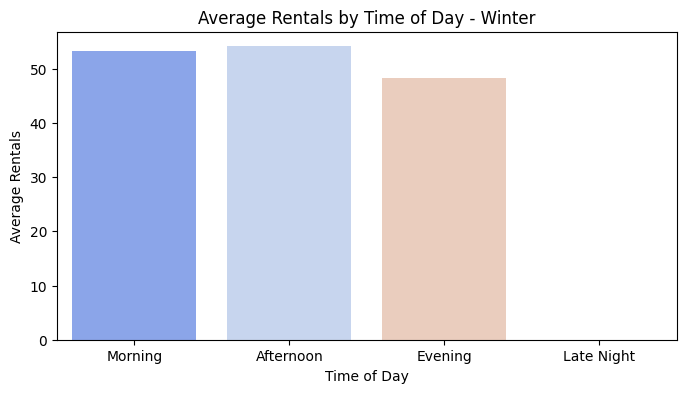

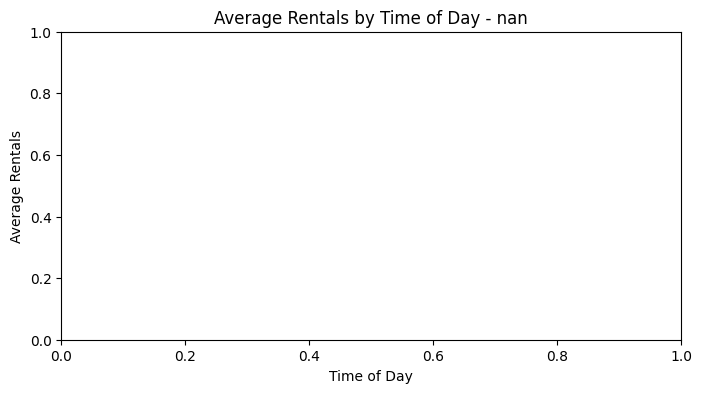

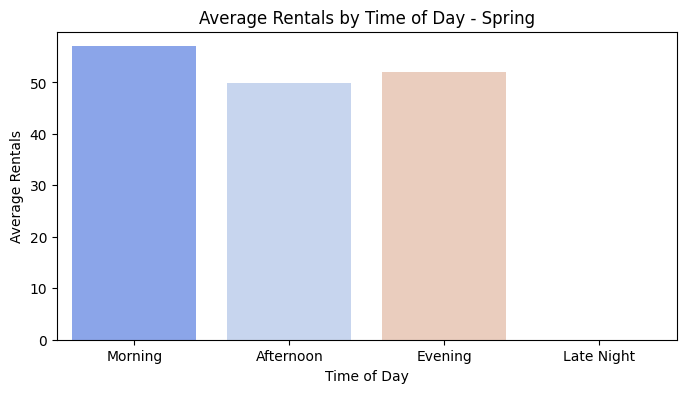

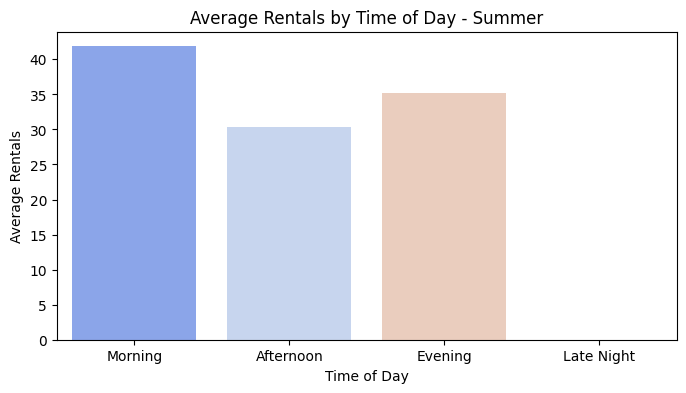

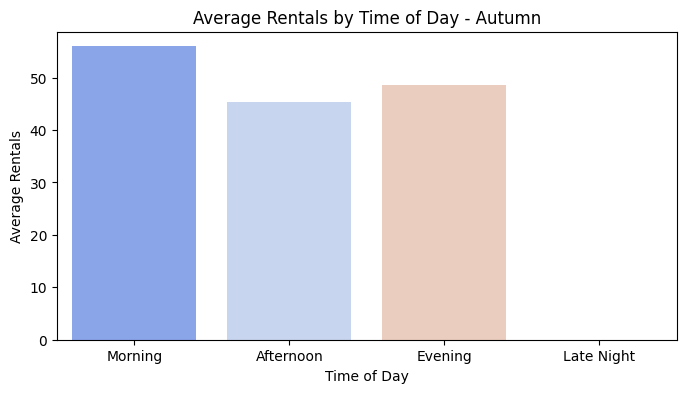

In [48]:
seasons = df['Season'].unique()

for season in seasons:
    plt.figure(figsize=(8, 4))
    season_data = df[df['Season'] == season]

    sns.barplot(x='Time_of_Day', y='Rentals_Count', data=season_data,
                order=['Morning', 'Afternoon', 'Evening', 'Late Night'],
                errorbar=None, palette='coolwarm')

    plt.title(f'Average Rentals by Time of Day - {season}')
    plt.xlabel('Time of Day')
    plt.ylabel('Average Rentals')
    plt.show()

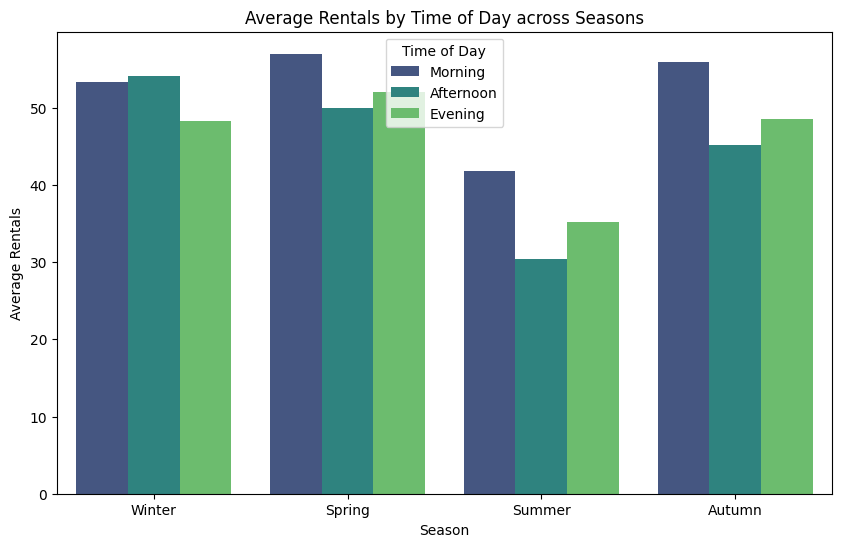

In [49]:
plt.figure(figsize=(10, 6))
sns.barplot(x='Season', y='Rentals_Count', hue='Time_of_Day', data=df, errorbar=None, palette='viridis')
plt.title('Average Rentals by Time of Day across Seasons')
plt.xlabel('Season')
plt.ylabel('Average Rentals')
plt.legend(title='Time of Day')
plt.show()

In [50]:
import numpy as np

df['Hour_Sin'] = np.sin(2 * np.pi * df['Hour'] / 23.0)
df['Hour_Cos'] = np.cos(2 * np.pi * df['Hour'] / 23.0)

df['Month_Sin'] = np.sin(2 * np.pi * df['Month'] / 12.0)
df['Month_Cos'] = np.cos(2 * np.pi * df['Month'] / 12.0)

print(df[['Hour', 'Hour_Sin', 'Hour_Cos', 'Month', 'Month_Sin', 'Month_Cos']].head())

   Hour  Hour_Sin  Hour_Cos  Month  Month_Sin  Month_Cos
0     9  0.631088 -0.775711      1        0.5   0.866025
1    10  0.398401 -0.917211      1        0.5   0.866025
2    14 -0.631088 -0.775711      1        0.5   0.866025
3    16 -0.942261 -0.334880      1        0.5   0.866025
4    18 -0.979084  0.203456      1        0.5   0.866025


---

# Part 6: Encoding and Preparing for ML

**Tasks**

1. Drop the `Date` column (we already extracted Month and Day)
2. Encode categorical variables — use `pd.get_dummies()` for one-hot encoding (or `LabelEncoder` where appropriate)
3. Define feature matrix `X` and target `y`
4. Split into 80% train / 20% test
5. Apply `StandardScaler` to features


In [51]:
# TODO: Drop the Date column
df = df.drop(columns=['Date'])

In [52]:
# TODO: One-hot encode categorical columns using pd.get_dummies()
df = pd.get_dummies(df, drop_first=True)

In [53]:
# TODO: Define X (everything except Rentals_Count) and y (Rentals_Count)
X = df.drop(columns=['Rentals_Count'])
y = df['Rentals_Count']

print("Feature matrix shape:", X.shape)
print("Target shape:", y.shape)


Feature matrix shape: (6367, 43)
Target shape: (6367,)


In [54]:
# TODO: Train/test split (80/20, random_state=42)
X_train, X_test, y_train, y_test = train_test_split(X, y, test_size=0.2, random_state=42)

print("Training set:", X_train.shape)
print("Test set:", X_test.shape)


Training set: (5093, 43)
Test set: (1274, 43)


In [55]:
# TODO: Initialize StandardScaler, fit on train, transform both train and test
scaler = StandardScaler()
X_train_scaled = scaler.fit_transform(X_train)
X_test_scaled = scaler.transform(X_test)

---

# Part 7: Model Building and Evaluation

We will build **4 different models** and compare their performance.

### Evaluation Metrics

- **R² (R-squared):** how much variance is explained by the model
- **MAE (Mean Absolute Error):** average absolute difference between predicted and actual
- **RMSE (Root Mean Squared Error):** penalizes large errors more heavily than MAE


## 7.1 Model 1 — Linear Regression

**Tasks**

1. Initialize and train a Linear Regression model
2. Make predictions on the test set
3. Calculate R², MAE, RMSE
4. Plot Actual vs Predicted scatter plot


In [56]:
# TODO: Initialize Linear Regression model
lr_model = LinearRegression()

In [57]:
# TODO: Train the model on X_train_scaled, y_train
lr_model.fit(X_train_scaled, y_train)

,fit_intercept,True
,copy_X,True
,tol,1e-06
,n_jobs,None
,positive,False


In [58]:
# TODO: Predict on X_test_scaled
y_pred_lr = lr_model.predict(X_test_scaled)

In [59]:
# TODO: Calculate and print R2, MAE, RMSE
r2_lr = r2_score(y_test, y_pred_lr)
mae_lr = mean_absolute_error(y_test, y_pred_lr)
rmse_lr = np.sqrt(mean_squared_error(y_test, y_pred_lr))

print(f"Linear Regression R2: {r2_lr:.4f}")
print(f"Linear Regression MAE: {mae_lr:.4f}")
print(f"Linear Regression RMSE: {rmse_lr:.4f}")

Linear Regression R2: 0.8817
Linear Regression MAE: 5.5025
Linear Regression RMSE: 7.2334


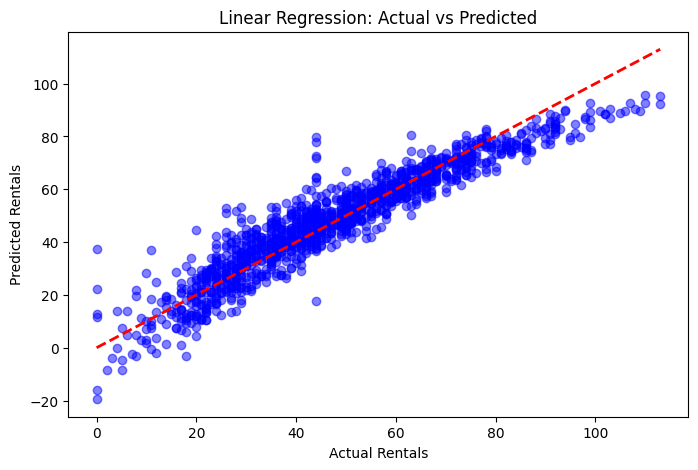

In [60]:
# TODO: Plot Actual vs Predicted
# plt.scatter(y_test, y_pred_lr, alpha=0.5)
# plt.plot([y_test.min(), y_test.max()], [y_test.min(), y_test.max()], 'r--')
plt.figure(figsize=(8, 5))
plt.scatter(y_test, y_pred_lr, alpha=0.5, color='blue')
plt.plot([y_test.min(), y_test.max()], [y_test.min(), y_test.max()], 'r--', lw=2)
plt.title('Linear Regression: Actual vs Predicted')
plt.xlabel('Actual Rentals')
plt.ylabel('Predicted Rentals')
plt.show()

## 7.2 Model 2 — Decision Tree Regressor

**Tasks**

1. Initialize a Decision Tree Regressor with `max_depth=10` and `random_state=42`
2. Train, predict, evaluate
3. Plot Actual vs Predicted
4. Plot the top 10 most important features


In [61]:
# TODO: Initialize Decision Tree Regressor
dt_model = DecisionTreeRegressor(max_depth=10, random_state=42)

In [62]:
# TODO: Train, predict, calculate R2/MAE/RMSE
dt_model.fit(X_train_scaled, y_train)
y_pred_dt = dt_model.predict(X_test_scaled)

r2_dt = r2_score(y_test, y_pred_dt)
mae_dt = mean_absolute_error(y_test, y_pred_dt)
rmse_dt = np.sqrt(mean_squared_error(y_test, y_pred_dt))

print(f"Decision Tree R2: {r2_dt:.4f}")
print(f"Decision Tree MAE: {mae_dt:.4f}")
print(f"Decision Tree RMSE: {rmse_dt:.4f}")

Decision Tree R2: 0.8423
Decision Tree MAE: 6.2295
Decision Tree RMSE: 8.3502


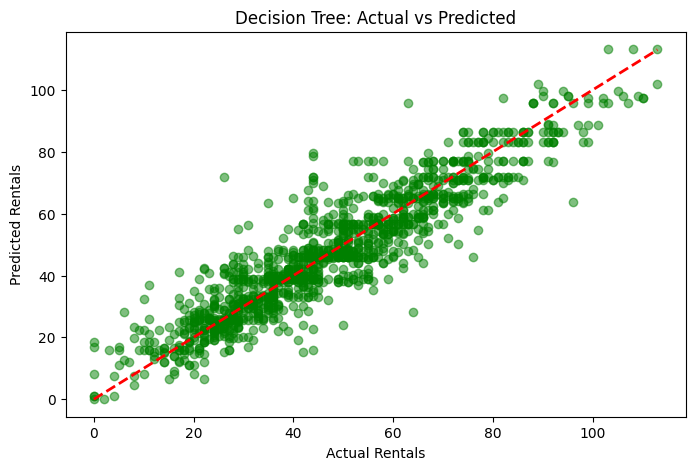

In [63]:
# TODO: Plot Actual vs Predicted
plt.figure(figsize=(8, 5))
plt.scatter(y_test, y_pred_dt, alpha=0.5, color='green')
plt.plot([y_test.min(), y_test.max()], [y_test.min(), y_test.max()], 'r--', lw=2)
plt.title('Decision Tree: Actual vs Predicted')
plt.xlabel('Actual Rentals')
plt.ylabel('Predicted Rentals')
plt.show()

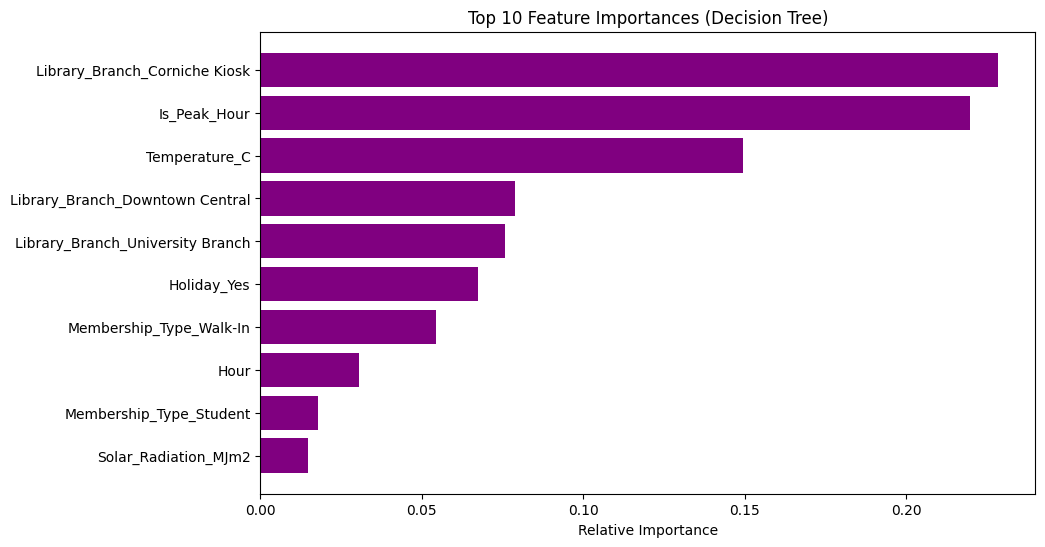

In [64]:
# TODO: Plot top 10 feature importances
# Hint: model.feature_importances_ gives you the values
# Use a horizontal bar chart sorted by importance
importances = dt_model.feature_importances_
feature_names = X.columns
indices = np.argsort(importances)[-10:]

plt.figure(figsize=(10, 6))
plt.barh(range(len(indices)), importances[indices], color='purple', align='center')
plt.yticks(range(len(indices)), [feature_names[i] for i in indices])
plt.title('Top 10 Feature Importances (Decision Tree)')
plt.xlabel('Relative Importance')
plt.show()

## 7.3 Model 3 — Random Forest Regressor

**Tasks**

1. Initialize a Random Forest with `n_estimators=100`, `max_depth=15`, `random_state=42`
2. Train, predict, evaluate
3. Plot Actual vs Predicted
4. Plot top 10 feature importances


In [65]:
# TODO: Initialize Random Forest Regressor
rf_model = RandomForestRegressor(n_estimators=100, max_depth=15, random_state=42)

In [66]:
# TODO: Train, predict, calculate R2/MAE/RMSE
rf_model.fit(X_train_scaled, y_train)
y_pred_rf = rf_model.predict(X_test_scaled)

r2_rf = r2_score(y_test, y_pred_rf)
mae_rf = mean_absolute_error(y_test, y_pred_rf)
rmse_rf = np.sqrt(mean_squared_error(y_test, y_pred_rf))

print(f"Random Forest R2: {r2_rf:.4f}")
print(f"Random Forest MAE: {mae_rf:.4f}")
print(f"Random Forest RMSE: {rmse_rf:.4f}")

Random Forest R2: 0.9139
Random Forest MAE: 4.4706
Random Forest RMSE: 6.1706


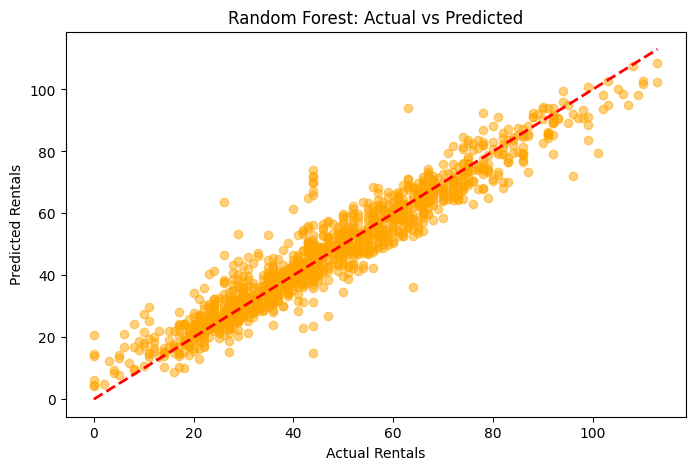

In [67]:
# TODO: Plot Actual vs Predicted
plt.figure(figsize=(8, 5))
plt.scatter(y_test, y_pred_rf, alpha=0.5, color='orange')
plt.plot([y_test.min(), y_test.max()], [y_test.min(), y_test.max()], 'r--', lw=2)
plt.title('Random Forest: Actual vs Predicted')
plt.xlabel('Actual Rentals')
plt.ylabel('Predicted Rentals')
plt.show()

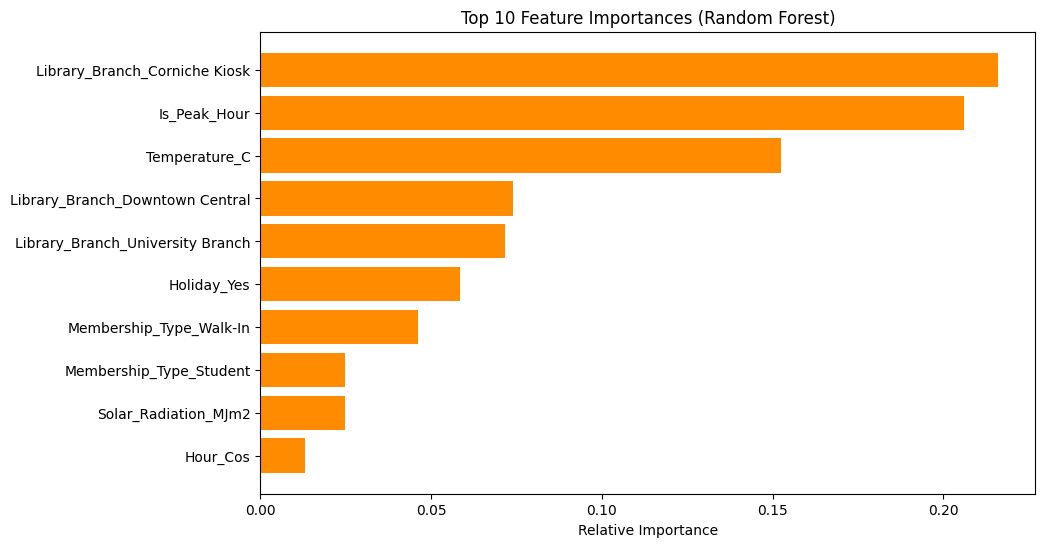

In [68]:
# TODO: Plot top 10 feature importances
importances_rf = rf_model.feature_importances_
indices_rf = np.argsort(importances_rf)[-10:]

plt.figure(figsize=(10, 6))
plt.barh(range(len(indices_rf)), importances_rf[indices_rf], color='darkorange', align='center')
plt.yticks(range(len(indices_rf)), [feature_names[i] for i in indices_rf])
plt.title('Top 10 Feature Importances (Random Forest)')
plt.xlabel('Relative Importance')
plt.show()

## 7.4 Model 4 — Neural Network

A neural network is a model loosely inspired by how the brain processes information. We will build a very simple one with just one hidden layer.

**Tasks**

1. Build a simple Sequential neural network with one hidden layer of 32 neurons (ReLU activation) and a single output neuron
2. Compile with `optimizer='adam'` and `loss='mse'`
3. Train for 50 epochs with `batch_size=32`
4. Predict on the test set and evaluate with R², MAE, RMSE


In [69]:
# TODO: Build a simple Neural Network with 1 hidden layer
# from tensorflow.keras.models import Sequential
# from tensorflow.keras.layers import Dense, Input
# Layer 1 (hidden): Dense(32, activation='relu')
# Layer 2 (output): Dense(1)
nn_model = Sequential()
nn_model.add(Dense(32, activation='relu', input_shape=(X_train_scaled.shape[1],)))
nn_model.add(Dense(1))


In [70]:
# TODO: Compile the model with optimizer='adam' and loss='mse'
nn_model.compile(optimizer='adam', loss='mse')

In [71]:
# TODO: Train the model for 50 epochs with batch_size=32
history = nn_model.fit(X_train_scaled, y_train, epochs=50, batch_size=32, verbose=1)

Epoch 1/50
160/160 ━━━━━━━━━━━━━━━━━━━━ 1s 523us/step - loss: 2424.0215
Epoch 2/50
160/160 ━━━━━━━━━━━━━━━━━━━━ 0s 453us/step - loss: 1760.3112
Epoch 3/50
160/160 ━━━━━━━━━━━━━━━━━━━━ 0s 512us/step - loss: 991.9164 
Epoch 4/50
160/160 ━━━━━━━━━━━━━━━━━━━━ 0s 524us/step - loss: 423.0392
Epoch 5/50
160/160 ━━━━━━━━━━━━━━━━━━━━ 0s 492us/step - loss: 161.7313
Epoch 6/50
160/160 ━━━━━━━━━━━━━━━━━━━━ 0s 571us/step - loss: 93.3026 
Epoch 7/50
160/160 ━━━━━━━━━━━━━━━━━━━━ 0s 616us/step - loss: 75.8595
Epoch 8/50
160/160 ━━━━━━━━━━━━━━━━━━━━ 0s 485us/step - loss: 67.1837
Epoch 9/50
160/160 ━━━━━━━━━━━━━━━━━━━━ 0s 453us/step - loss: 61.1363
Epoch 10/50
160/160 ━━━━━━━━━━━━━━━━━━━━ 0s 487us/step - loss: 56.5059
Epoch 11/50
160/160 ━━━━━━━━━━━━━━━━━━━━ 0s 645us/step - loss: 52.7824
Epoch 12/50
160/160 ━━━━━━━━━━━━━━━━━━━━ 0s 619us/step - loss: 49.6309
Epoch 13/50
160/160 ━━━━━━━━━━━━━━━━━━━━ 0s 567us/step - loss: 47.2332
Epoch 14/50
160/160 ━━━━━━━━━━━━━━━━━━━━ 0s 564us/step - loss: 45.1288
Epoch 

In [72]:
# TODO: Predict on X_test_scaled
# Hint: model.predict() returns 2D, use .flatten() to make it 1D
y_pred_nn = nn_model.predict(X_test_scaled).flatten()

40/40 ━━━━━━━━━━━━━━━━━━━━ 0s 864us/step


In [73]:
# TODO: Calculate and print R2, MAE, RMSE
r2_nn = r2_score(y_test, y_pred_nn)
mae_nn = mean_absolute_error(y_test, y_pred_nn)
rmse_nn = np.sqrt(mean_squared_error(y_test, y_pred_nn))

print(f"Neural Network R2: {r2_nn:.4f}")
print(f"Neural Network MAE: {mae_nn:.4f}")
print(f"Neural Network RMSE: {rmse_nn:.4f}")

Neural Network R2: 0.9267
Neural Network MAE: 4.1148
Neural Network RMSE: 5.6948


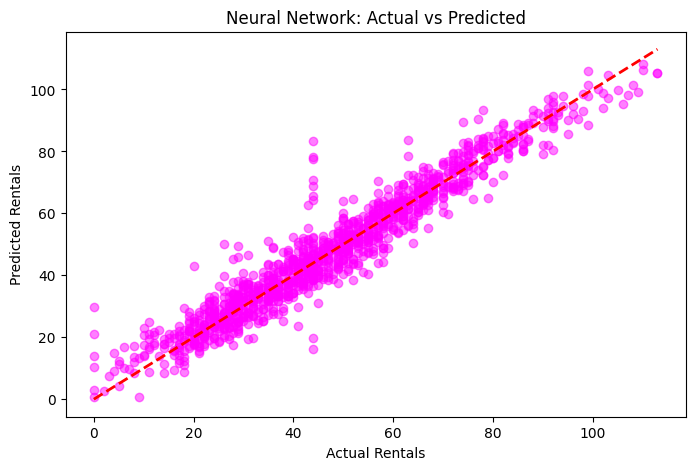

In [74]:
# TODO: Plot Actual vs Predicted
plt.figure(figsize=(8, 5))
plt.scatter(y_test, y_pred_nn, alpha=0.5, color='magenta')
plt.plot([y_test.min(), y_test.max()], [y_test.min(), y_test.max()], 'r--', lw=2)
plt.title('Neural Network: Actual vs Predicted')
plt.xlabel('Actual Rentals')
plt.ylabel('Predicted Rentals')
plt.show()

In [75]:
from sklearn.ensemble import HistGradientBoostingRegressor

hgb_model = HistGradientBoostingRegressor(max_iter=200, learning_rate=0.1, random_state=42)
hgb_model.fit(X_train_scaled, y_train)

y_pred_hgb = hgb_model.predict(X_test_scaled)

r2_hgb = r2_score(y_test, y_pred_hgb)
mae_hgb = mean_absolute_error(y_test, y_pred_hgb)
rmse_hgb = np.sqrt(mean_squared_error(y_test, y_pred_hgb))

print(f"HistGradientBoosting R2: {r2_hgb:.4f}")
print(f"HistGradientBoosting MAE: {mae_hgb:.4f}")
print(f"HistGradientBoosting RMSE: {rmse_hgb:.4f}")



HistGradientBoosting R2: 0.9500
HistGradientBoosting MAE: 3.3233
HistGradientBoosting RMSE: 4.7004


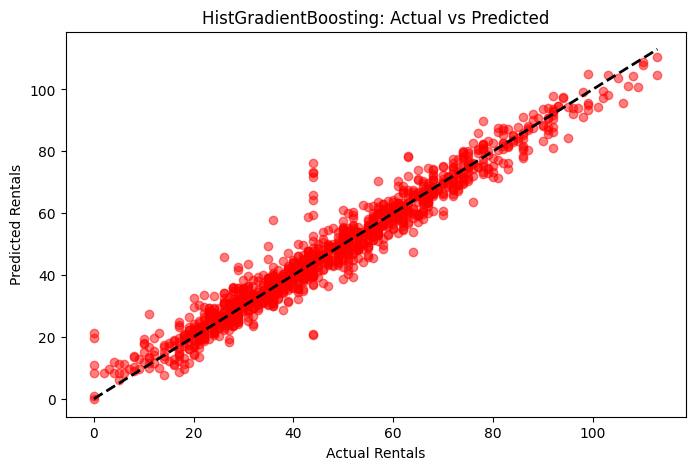

In [76]:
plt.figure(figsize=(8, 5))
plt.scatter(y_test, y_pred_hgb, alpha=0.5, color='red')
plt.plot([y_test.min(), y_test.max()], [y_test.min(), y_test.max()], 'k--', lw=2)
plt.title('HistGradientBoosting: Actual vs Predicted')
plt.xlabel('Actual Rentals')
plt.ylabel('Predicted Rentals')
plt.show()

In [77]:
X_train['Temp_Humidity_Interaction'] = X_train['Temperature_C'] * X_train['Humidity_pct']
X_test['Temp_Humidity_Interaction'] = X_test['Temperature_C'] * X_test['Humidity_pct']

from sklearn.ensemble import HistGradientBoostingRegressor

hgb_optimized = HistGradientBoostingRegressor(
    max_iter=300,
    learning_rate=0.05,
    max_depth=10,
    random_state=42
)

hgb_optimized.fit(X_train, y_train)

y_pred_opt = hgb_optimized.predict(X_test)

print(f"Optimized HistGradientBoosting R2: {r2_score(y_test, y_pred_opt):.4f}")

Optimized HistGradientBoosting R2: 0.9515


---

# Part 8: Model Comparison

**Tasks**

1. Build a summary DataFrame comparing all 4 models on R², MAE, RMSE
2. Plot a bar chart comparing R² scores
3. Write a short conclusion (3–5 sentences)


In [78]:
# TODO: Build a comparison DataFrame
# Columns: Model, R2, MAE, RMSE
# Rows: Linear Regression, Decision Tree, Random Forest, Neural Network

# Calculate metrics for hgb_optimized
r2_opt = r2_score(y_test, y_pred_opt)
mae_opt = mean_absolute_error(y_test, y_pred_opt)
rmse_opt = np.sqrt(mean_squared_error(y_test, y_pred_opt))

models_data = {
    'Model': ['Linear Regression', 'Decision Tree', 'Random Forest', 'Neural Network', 'HistGradientBoosting', 'hgb_optimized'],
    'R2': [r2_lr, r2_dt, r2_rf, r2_nn, r2_hgb, r2_opt],
    'MAE': [mae_lr, mae_dt, mae_rf, mae_nn, mae_hgb, mae_opt],
    'RMSE': [rmse_lr, rmse_dt, rmse_rf, rmse_nn, rmse_hgb, rmse_opt]
}
comparison_df = pd.DataFrame(models_data)

In [79]:
# TODO: Display the comparison table
comparison_df.sort_values(by='R2', ascending=False)

,Model,R2,MAE,RMSE
5,hgb_optimized,0.951461,3.262431,4.632801
4,HistGradientBoosting,0.950034,3.323317,4.700394
3,Neural Network,0.926657,4.114811,5.694784
2,Random Forest,0.913889,4.470596,6.170585
0,Linear Regression,0.881671,5.502517,7.233412
1,Decision Tree,0.842314,6.229464,8.350156


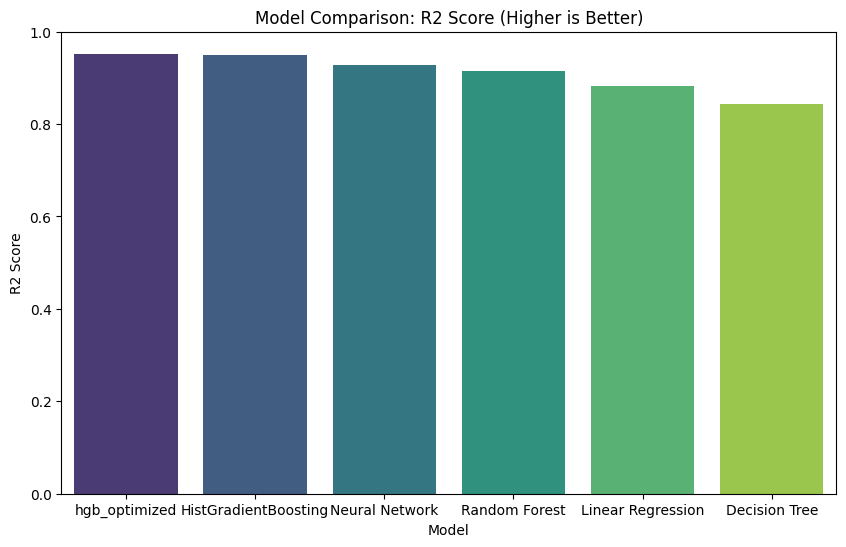

In [80]:
# TODO: Bar chart of R2 scores for all 4 models
plt.figure(figsize=(10, 6))
sns.barplot(x='Model', y='R2', data=comparison_df.sort_values(by='R2', ascending=False), palette='viridis')
plt.title('Model Comparison: R2 Score (Higher is Better)')
plt.ylim(0, 1)
plt.ylabel('R2 Score')
plt.show()

## Conclusion

Write 3–5 sentences answering:

1. Which model performed best on this dataset?
2. Why do you think that model outperformed the others?
3. Which features were most important for predicting rentals?
4. What would you recommend to library management based on your findings?

*Write your answer here:*


---

# Submission Checklist

- [ ] Data is fully cleaned (no missing values, no negative rentals, no duplicates)
- [ ] All categorical columns are consistently formatted
- [ ] At least 6 EDA visualizations are completed with titles and labels
- [ ] Feature engineering: `Month`, `Day`, `Is_Peak_Hour`, `Temperature_Bin`, `Is_Weekend` created
- [ ] Categorical variables are encoded
- [ ] Data is split into train/test and scaled
- [ ] **Model 1 — Linear Regression** trained and evaluated
- [ ] **Model 2 — Decision Tree** trained and evaluated with feature importance
- [ ] **Model 3 — Random Forest** trained and evaluated with feature importance
- [ ] **Model 4 — Neural Network** trained and evaluated
- [ ] All 4 models compared in a summary table and bar chart
- [ ] Conclusion written with recommendations


In [ ]:
from skl2onnx import to_onnx
from skl2onnx.common.data_types import FloatTensorType 
import numpy as np
import os

output_dir = "../Models"
if not os.path.exists(output_dir):
    os.makedirs(output_dir)

initial_type = [('float_input', FloatTensorType([None, X_train.shape[1]]))]

onx = to_onnx(hgb_optimized, X_train.astype(np.float32), initial_types=initial_type)

with open(os.path.join(output_dir, "model.onnx"), "wb") as f:
    f.write(onx.SerializeToString())

print("Model saved as ONNX successfully in Models/ folder!")

Model saved as ONNX successfully in Models/ folder!


In [96]:
print(list(X_train.columns))

['Hour', 'Temperature_C', 'Humidity_pct', 'Wind_Speed_ms', 'Visibility_m', 'Solar_Radiation_MJm2', 'Rainfall_mm', 'Month', 'Day', 'Is_Peak_Hour', 'Is_Weekend', 'Hour_Sin', 'Hour_Cos', 'Month_Sin', 'Month_Cos', 'Season_Spring', 'Season_Summer', 'Season_Winter', 'Holiday_Yes', 'Library_Branch_Al Rawdah Branch', 'Library_Branch_Corniche Kiosk', 'Library_Branch_Downtown Central', 'Library_Branch_University Branch', 'Top_Category_Business', 'Top_Category_Children', 'Top_Category_Fiction', 'Top_Category_History', 'Top_Category_Non-Fiction', 'Top_Category_Science', 'Top_Category_Technology', 'Membership_Type_Regular', 'Membership_Type_Student', 'Membership_Type_Walk-In', 'Day_of_Week_Monday', 'Day_of_Week_Saturday', 'Day_of_Week_Sunday', 'Day_of_Week_Thursday', 'Day_of_Week_Tuesday', 'Day_of_Week_Wednesday', 'Temperature_Bin_Warm', 'Temperature_Bin_Hot', 'Time_of_Day_Evening', 'Time_of_Day_Morning', 'Temp_Humidity_Interaction']
